In [124]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

In [125]:
df = pd.read_csv('data/housing_final.csv')
df = df[df['median_house_value'] != 500001.0]

In [126]:
ocean_cols = [col for col in df.columns if 'ocean_proximity_' in col]
for col in ocean_cols:
    df[col] = df[col].astype(int)

In [127]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [128]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
alphas = np.logspace(-3, 3, 30)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=20000))
])
pipe.fit(X, y)
coefs = pd.Series(pipe.named_steps['lasso'].coef_, index=X.columns)
selected = coefs[coefs != 0]
features = selected.index.tolist()

In [129]:
X = df[features]
y = df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

max_price = y_train.max()
min_price = y_train.min()

## Ridge (L2) z CV

In [130]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 30)
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas, cv=5))
])

ridge.fit(X_train, y_train)

ridge_model = ridge.named_steps['ridge']
print(f"Ridge: wybrane alpha={ridge_model.alpha_:.4f}")

y_pred_train_ridge = np.clip(ridge.predict(X_train), min_price, max_price)
y_pred_test_ridge  = np.clip(ridge.predict(X_test),  min_price, max_price)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge  = np.sqrt(mean_squared_error(y_test,  y_pred_test_ridge))
r2_train_ridge   = r2_score(y_train, y_pred_train_ridge)
r2_test_ridge    = r2_score(y_test,  y_pred_test_ridge)

print("="*50)
print("RIDGE (L2)")
print("="*50)
print(f"Train RMSE: ${rmse_train_ridge:,.2f}")
print(f"Test RMSE:  ${rmse_test_ridge:,.2f}")
print(f"Train R²:   {r2_train_ridge:.4f}")
print(f"Test R²:    {r2_test_ridge:.4f}")
print("="*50)


Ridge: wybrane alpha=8.5317
RIDGE (L2)
Train RMSE: $60,050.88
Test RMSE:  $61,432.72
Train R²:   0.6180
Test R²:    0.6215


In [131]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
alphas = np.logspace(-3, 3, 30)
ridge_lin = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas, cv=5))
])

ridge_lin.fit(X_train, y_train)

ridge_lin_model = ridge_lin.named_steps['ridge']
print(f"Ridge (L2) Linear: wybrane alpha={ridge_lin_model.alpha_:.4f}")

y_pred_train_lin = np.clip(ridge_lin.predict(X_train), min_price, max_price)
y_pred_test_lin = np.clip(ridge_lin.predict(X_test), min_price, max_price)

rmse_train_lin = np.sqrt(mean_squared_error(y_train, y_pred_train_lin))
rmse_test_lin = np.sqrt(mean_squared_error(y_test, y_pred_test_lin))
r2_train_lin = r2_score(y_train, y_pred_train_lin)
r2_test_lin = r2_score(y_test, y_pred_test_lin)

print("="*50)
print(f"Train RMSE: ${rmse_train_lin:,.2f}")
print(f"Test RMSE:  ${rmse_test_lin:,.2f}")
print(f"Train R²:   {r2_train_lin:.4f}")
print(f"Test R²:    {r2_test_lin:.4f}")
print("="*50)

Ridge (L2) Linear: wybrane alpha=8.5317
Train RMSE: $60,050.88
Test RMSE:  $61,432.72
Train R²:   0.6180
Test R²:    0.6215


## Decision Tree

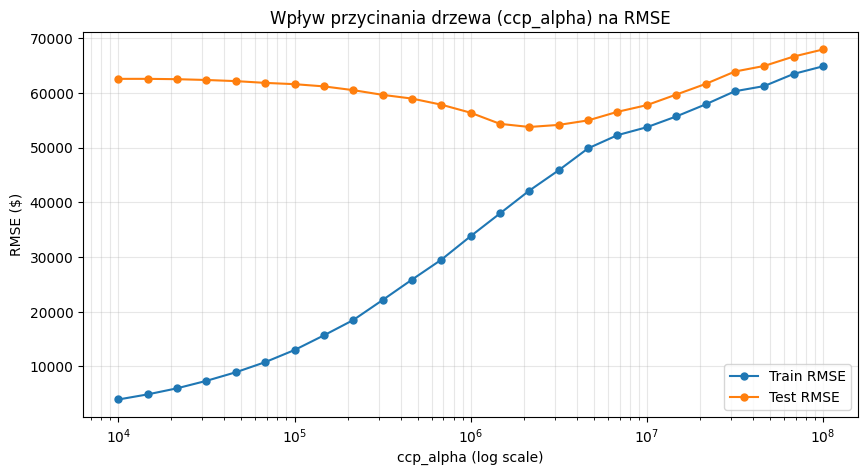

Optymalne ccp_alpha: 2154434.69, Test RMSE: $53,754.05


In [132]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

max_price = y_train.max()
min_price = y_train.min()

ccp_alphas = np.logspace(4, 8, 25) 

rmse_test_ccp = []
rmse_train_ccp = []

for ccp in ccp_alphas:
    tree = DecisionTreeRegressor(max_depth=None, random_state=42, ccp_alpha=ccp)
    tree.fit(X_train, y_train)
    y_pred_train = tree.predict(X_train)
    y_pred_test = tree.predict(X_test)
    rmse_train_ccp.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    rmse_test_ccp.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

plt.figure(figsize=(10,5))
plt.semilogx(ccp_alphas, rmse_train_ccp, label='Train RMSE', marker='o', markersize=5)
plt.semilogx(ccp_alphas, rmse_test_ccp, label='Test RMSE', marker='o', markersize=5)
plt.xlabel('ccp_alpha (log scale)')
plt.ylabel('RMSE ($)')
plt.title('Wpływ przycinania drzewa (ccp_alpha) na RMSE')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.show()

best_ccp = ccp_alphas[np.argmin(rmse_test_ccp)]
print(f'Optymalne ccp_alpha: {best_ccp:.2f}, Test RMSE: ${min(rmse_test_ccp):,.2f}')

In [133]:
print("\n" + "="*50)
print("DECISION TREE - WYBÓR GŁĘBOKOŚCI")
print("="*50)

depths = [3, 5, 10, 15, 20, 30, None]
best_tree_depth = None
best_tree_score = float('inf')

for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42, ccp_alpha=best_ccp)
    tree.fit(X_train, y_train)
    y_pred_test_temp = np.clip(tree.predict(X_test), min_price, max_price)
    rmse_test_temp = np.sqrt(mean_squared_error(y_test, y_pred_test_temp))
    r2_test_temp = r2_score(y_test, y_pred_test_temp)
    depth_str = str(depth) if depth else "None"
    print(f"Depth={depth_str:<4} | Test RMSE: ${rmse_test_temp:>10,.2f} | R²: {r2_test_temp:.4f}")
    if rmse_test_temp < best_tree_score:
        best_tree_score = rmse_test_temp
        best_tree_depth = depth
        best_tree_model = tree

print(f"\nWybrano: max_depth={best_tree_depth}, Test RMSE=${best_tree_score:,.2f}")


DECISION TREE - WYBÓR GŁĘBOKOŚCI
Depth=3    | Test RMSE: $ 69,159.67 | R²: 0.5203
Depth=5    | Test RMSE: $ 64,350.84 | R²: 0.5847
Depth=10   | Test RMSE: $ 54,709.86 | R²: 0.6998
Depth=15   | Test RMSE: $ 53,768.07 | R²: 0.7101
Depth=20   | Test RMSE: $ 53,755.45 | R²: 0.7102
Depth=30   | Test RMSE: $ 53,699.35 | R²: 0.7108
Depth=None | Test RMSE: $ 53,754.05 | R²: 0.7102

Wybrano: max_depth=30, Test RMSE=$53,699.35


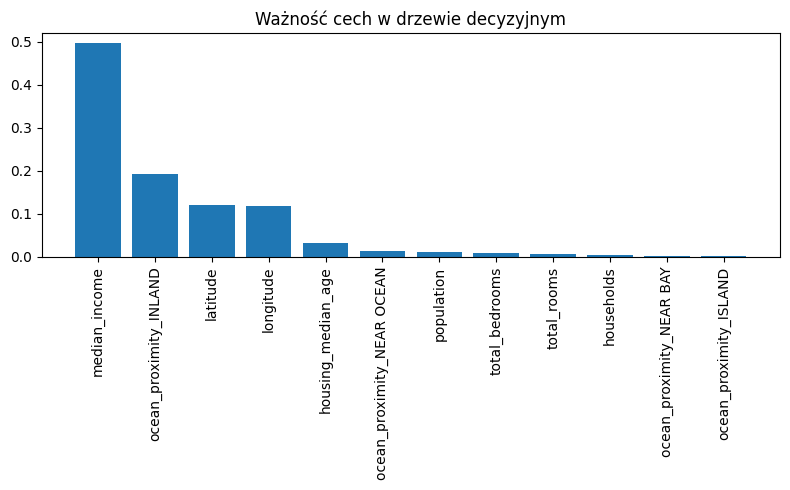

1. median_income: 0.4956
2. ocean_proximity_INLAND: 0.1920
3. latitude: 0.1201
4. longitude: 0.1171
5. housing_median_age: 0.0314
6. ocean_proximity_NEAR OCEAN: 0.0127
7. population: 0.0098
8. total_bedrooms: 0.0093
9. total_rooms: 0.0062
10. households: 0.0042


In [134]:
# Ważność cech dla drzewa decyzyjnego
# (wykonaj tę komórkę po wytrenowaniu best_tree_model na wszystkich cechach)
importances = best_tree_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(8,5))
plt.title("Ważność cech w drzewie decyzyjnym")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# Najważniejsze cechy:
for i in range(min(10, len(importances))):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

In [135]:
# Wybierz najważniejsze cechy wg drzewa (np. top 8)
top_n = 8
important_features = [feature_names[i] for i in indices[:top_n]]

# Użyj tylko tych cech do finalnego drzewa
df_tree = df[important_features]
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(df_tree, y, test_size=0.2, random_state=42)

final_tree = DecisionTreeRegressor(max_depth=best_tree_depth, random_state=42, ccp_alpha=best_ccp)
final_tree.fit(X_train_tree, y_train_tree)

y_pred_train_tree = np.clip(final_tree.predict(X_train_tree), min_price, max_price)
y_pred_test_tree = np.clip(final_tree.predict(X_test_tree), min_price, max_price)

rmse_train_tree = np.sqrt(mean_squared_error(y_train_tree, y_pred_train_tree))
rmse_test_tree = np.sqrt(mean_squared_error(y_test_tree, y_pred_test_tree))
r2_test_tree = r2_score(y_test_tree, y_pred_test_tree)

## Porównanie modeli

In [137]:
print("\n" + "="*80)
print("PORÓWNANIE MODELI")
print("="*80)
print(f"{'Model':<35} {'Train RMSE':<15} {'Test RMSE':<15} {'Test R²':<10}")
print("-"*80)
print(f"{'Ridge (L2) Linear Regression':<35} ${rmse_train_lin:<14,.2f} ${rmse_test_lin:<14,.2f} {r2_test_lin:.4f}")
depth_label = f"Decision Tree (max_depth={best_tree_depth})"
print(f"{depth_label:<35} ${rmse_train_tree:<14,.2f} ${rmse_test_tree:<14,.2f} {r2_test_tree:.4f}")
print("="*80)


PORÓWNANIE MODELI
Model                               Train RMSE      Test RMSE       Test R²   
--------------------------------------------------------------------------------
Ridge (L2) Linear Regression        $60,050.88      $61,432.72      0.6215
Decision Tree (max_depth=30)        $42,527.69      $53,537.97      0.7125
